In [8]:
from astropy.io import ascii

import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


%load_ext autoreload
%autoreload 2

    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# from consolidate_photometry import get_fastspec_fit_catalog_V2

In [10]:
# get_fastspec_fit_catalog_V2()

In [11]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main =  Table.read(filename, hdu="MAIN")
fastspec =  Table.read(filename, hdu="FASTSPEC")


In [28]:
fastspec[:3]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,ABSMAG01_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_SDSS_I,ABSMAG01_SDSS_Z,ABSMAG01_IVAR_SDSS_G,ABSMAG01_IVAR_SDSS_R,ABSMAG01_IVAR_SDSS_I,ABSMAG01_IVAR_SDSS_Z,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,FLUX_SYNTH_G,FLUX_SYNTH_R,FLUX_SYNTH_Z,FLUX_SYNTH_SPECMODEL_G,FLUX_SYNTH_SPECMODEL_R,FLUX_SYNTH_SPECMODEL_Z,FLUX_SYNTH_PHOTMODEL_G,FLUX_SYNTH_PHOTMODEL_R,FLUX_SYNTH_PHOTMODEL_Z
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
39627066986994125,58.82791003142589,-31.167992883134954,0.7362137,1.4110432,1.4763778,17.617802,16.742657,18.288889,17.617802,0.13864987,0.0036776955,1.2419373,0.003478581,0.0038752842,0.04712536,8.606093,0.10930019,3.6840034,0.12549414,2.1664715,0.12482052,6.525919,0.13526016,5.365553,0.25182992,1.139345,0.45386365,13.020986,0.5125305,0.0,0.0,3.3743422,0.46464396,6.9175406,0.40019593,4.389449,0.42514646,3.668044,0.1432467,0.0,0.0,11.785126,0.31097978,16.42255,0.17391735,-16.49879,-16.979223,-17.099663,-17.20152,68639.96,95766.43,95766.43,17303.523,0.6386112,0.5914388,21.08646,1.2983865,125.0,0.0,2.7566395,3.5999548,4.5907245,2.8437536,3.7306423,4.698892,49.14909,63.76746,78.488754
39627067007963313,60.226366678070214,-31.212205289954937,1.4132357,3.5321915,3.6635215,2.4283745,2.4283745,2.533538,2.3881364,37.9116,0.025306156,53.710964,0.025880195,0.0,0.0,0.32450342,0.12797481,24.881557,0.13946308,15.761389,0.12885329,47.488174,0.12558246,5.8847404,0.6891925,3.7865758,1.0381052,81.621704,0.35001734,0.0,0.0,11.170705,0.99730766,19.486305,0.8831486,13.733435,0.9514775,5.941074,0.59739685,0.0,0.0,80.51231,0.23694395,40.415253,0.17269689,-17.121216,-17.516224,-17.740263,-17.803177,109621.5,161901.06,161901.06,31385.21,1.1979301,1.1641659,60.714848,1.2201538,125.0,0.0,6.773899,9.098611,12.818543,6.905595,9.428278,12.723417,16.97218,23.012527,29.593266
39627072187928583,60.4180052720939,-30.957836153152165,1.0133064,2.5961263,2.8812685,2.6278307,2.7878876,2.6278307,2.4664397,39.23421,0.03122736,49.01422,0.030052872,0.0,0.0,0.0043020747,0.23753567,25.520433,0.2441208,24.53631,0.27351534,70.86685,0.14695764,2.807333,0.63469523,2.5821435,1.1553512,82.53656,0.25459012,0.0,0.0,7.6372366,1.1897672,15.090424,1.076403,8.002247,0.9886692,5.494466,0.53002375,0.0,0.0,84.61228,0.19245377,47.66704,0.085225895,-16.648767,-17.089336,-17.350178,-17.413273,87703.98,126592.66,126592.66,22972.041,1.2962124,1.1999841,23.135845,1.341978,125.0,0.0,4.194651,7.0231385,9.429502,4.7626886,6.9917912,9.530589,12.428275,18.421305,24.248781


## Effect of nebular emission lines on spectra!!

This would be hard to do for shredded galaxies or objects with significant SED variation ... but is more meant to show the level of effect one would expect ...
This is especialyl because the M24 stellar mass method was not trained on spectra with emission line so systematics 

In [17]:
## I think one excersie would be to focus on BGS Bright galaxies, take galaxies in bins of Halpha EW

## that probably traces g-r pretty well..
gr = main["MAG_G"].data - main["MAG_R"].data

In [ ]:
## essentially in bins of Halpha EW, fit the stellar continuum and subtract the 

/tmp/ipykernel_177117/1828849967.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )
/tmp/ipykernel_177117/1828849967.py:1: RuntimeWarning: invalid value encountered in log10
  plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )


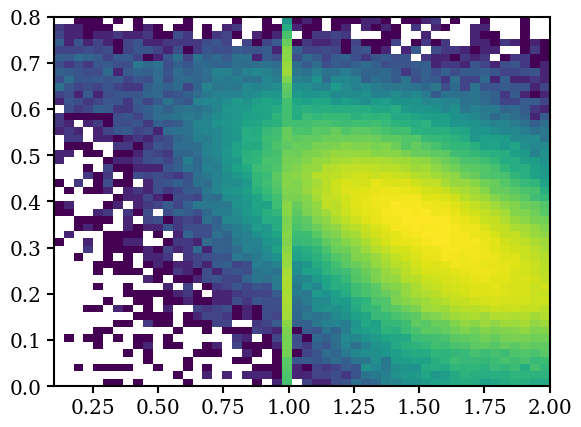

In [20]:
plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )
plt.xlim(0.1,2)
plt.show()

In [21]:
stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/fastspec_stack_mstar_elg_7.50_7.75.fits"


In [27]:
Table(fits.open(stack_path)[2].data)

STACKID,SURVEY,PROGRAM,SEED,COEFF,RCHI2,RCHI2_LINE,RCHI2_CONT,RCHI2_PHOT,VDISP,VDISP_IVAR,TAUV,TAUV_IVAR,AGE,AGE_IVAR,ZZSUN,ZZSUN_IVAR,LOGMSTAR,LOGMSTAR_IVAR,SFR,SFR_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,DN4000_MODEL_IVAR,FLUX_SYNTH_G,FLUX_SYNTH_R,FLUX_SYNTH_Z,FLUX_SYNTH_SPECMODEL_G,FLUX_SYNTH_SPECMODEL_R,FLUX_SYNTH_SPECMODEL_Z,FLUX_SYNTH_PHOTMODEL_G,FLUX_SYNTH_PHOTMODEL_R,FLUX_SYNTH_PHOTMODEL_Z,ABSMAG01_SDSS_U,ABSMAG01_IVAR_SDSS_U,ABSMAG01_SYNTH_SDSS_U,ABSMAG01_SYNTH_IVAR_SDSS_U,ABSMAG01_SDSS_G,ABSMAG01_IVAR_SDSS_G,ABSMAG01_SYNTH_SDSS_G,ABSMAG01_SYNTH_IVAR_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_IVAR_SDSS_R,ABSMAG01_SYNTH_SDSS_R,ABSMAG01_SYNTH_IVAR_SDSS_R,ABSMAG01_SDSS_I,ABSMAG01_IVAR_SDSS_I,ABSMAG01_SYNTH_SDSS_I,ABSMAG01_SYNTH_IVAR_SDSS_I,ABSMAG01_SDSS_Z,ABSMAG01_IVAR_SDSS_Z,ABSMAG01_SYNTH_SDSS_Z,ABSMAG01_SYNTH_IVAR_SDSS_Z,KCORR01_SDSS_U,KCORR01_SDSS_G,KCORR01_SDSS_R,KCORR01_SDSS_I,KCORR01_SDSS_Z,LOGLNU_1500,LOGLNU_1500_IVAR,LOGLNU_2800,LOGLNU_2800_IVAR,LOGL_1450,LOGL_1450_IVAR,LOGL_1700,LOGL_1700_IVAR,LOGL_3000,LOGL_3000_IVAR,LOGL_5100,LOGL_5100_IVAR,FLYA_1215_CONT,FLYA_1215_CONT_IVAR,FOII_3727_CONT,FOII_3727_CONT_IVAR,FHBETA_CONT,FHBETA_CONT_IVAR,FOIII_5007_CONT,FOIII_5007_CONT_IVAR,FHALPHA_CONT,FHALPHA_CONT_IVAR
int64,str7,str7,int64,float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
0,stacked,stacked,2032329983,0.00015870707 .. 2.5564117e-05,4.1402636,4.152481,1.3553507,0.0,250.0,0.0,0.6821338,136.36362,5.47049,25.186127,0.0,0.0,9.414582,1367.0154,0.047603495,22986.037,1.1606756,1.1106957,29589.857,1.1604128,90445.16,0.046748318,0.05939372,0.10663942,0.046542063,0.05903361,0.10467964,0.04404268,0.05567805,0.07331155,24.512762,0.0,24.512762,6656.9946,23.674475,0.0,23.674475,989998.6,23.3633,0.0,23.3633,3989992.5,23.207424,0.0,23.207424,587191.7,23.063087,0.0,23.063087,471755.06,-1.0066103,-0.16832228,0.14285184,0.044202495,-0.11018098,-0.54702777,614.20654,-0.2511177,13932.878,-0.82648134,537.2081,-0.8060381,973.73865,-0.7865613,20942.977,-0.5661453,2632168.0,0.03171362,70683.016,0.015805217,91310470.0,0.021125114,3847332900.0,0.019791437,5303800300.0,0.014341359,9110373000.0
1,stacked,stacked,2198257139,0.00012471003 .. 1.6600852e-08,4.920896,4.9343867,2.2582426,0.0,250.0,0.0,0.5927002,170.50142,5.6086173,32.186077,0.0,0.0,9.430902,1732.5243,0.03740623,63320.53,1.1579796,1.1069071,29969.717,1.1640646,110716.81,0.046817552,0.059472233,0.10756093,0.046569742,0.059030037,0.104580365,0.044040166,0.05562852,0.07309141,24.500648,0.0,24.500648,8089.4116,23.6738,0.0,23.6738,1770666.2,23.363026,0.0,23.363026,5663037.0,23.209116,0.0,23.209116,737139.4,23.06439,0.0,23.06439,689209.94,-0.9944346,-0.1675859,0.14318958,0.043477673,-0.10821946,-0.50598174,758.77234,-0.24268329,17273.748,-0.7829338,643.14984,-0.7731116,1219.7853,-0.78011477,25553.703,-0.56641656,3269095.0,0.03602388,86354.47,0.015918404,104141176.0,0.02115646,9703790000.0,0.01979601,6635965400.0,0.014339971,12699746000.0
2,stacked,stacked,3243419750,0.00013744862 .. 1.3842256e-05,5.0141115,5.028772,2.1870718,0.0,250.0,0.0,0.60485584,107.6632,5.589835,30.7782,0.0,0.0,9.424868,1798.1034,0.041227113,30380.854,1.1708702,1.1187226,28719.924,1.1633488,63199.426,0.04649288,0.058563333,0.102736525,0.046281498,0.05863731,0.10383321,0.04375009,0.055253256,0.0725866,24.508543,0.0,24.508543,5559.166,23.680984,0.0,23.680984,1416963.1,23.370728,0.0,23.370728,8570728.0,23.216288,0.0,23.216288,935128.56,23.072256,0.0,2

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
# clean_cat = clean_cat[:50000]

In [ ]:
##match the clean cat with other catalogs
gswlc_cat = ascii.read("/pscratch/sd/v/virajvm/desi2_lowz_data/catalogs/GSWLC-X2.dat")
iron = SkyCoord(np.array(clean_cat["RA"])*u.degree, np.array(clean_cat["DEC"])*u.degree  )
gswlc = SkyCoord(np.array(gswlc_cat["RA"])*u.degree, np.array(gswlc_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(gswlc)
clean_cat_gswlc_match = clean_cat[d2d.arcsec < 1]
gswlc_match = gswlc_cat[idx][d2d.arcsec < 1]

##these are stellar masses from Hu Zhou XMPG paper. They also use CIGALE here and no AGN is used
hu_cat= Table.read("/global/cfs/cdirs/desi/users/dscholte/data_to_share/sample_catalog_viraj_29052024.fits")
iron = SkyCoord(np.array(clean_cat["RA"])*u.degree, np.array(clean_cat["DEC"])*u.degree  )
hu = SkyCoord(np.array(hu_cat["RA"])*u.degree, np.array(hu_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(hu)
clean_cat_hu_match = clean_cat[d2d.arcsec < 1]
hu_match = hu_cat[idx][d2d.arcsec < 1]

###FASTSPECFIT
print("Reading fastspecfit!")
iron_vac = fits.open("/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits")
fspec_mstar = iron_vac[1].data["LOGMSTAR"]
fspec_ra = iron_vac[2].data["RA"]
fspec_dec = iron_vac[2].data["DEC"]
catalog = SkyCoord(ra= fspec_ra* u.degree, dec= fspec_dec*u.degree )
c = SkyCoord(ra=np.array(clean_cat["RA"])*u.degree, dec=np.array(clean_cat["DEC"])*u.degree )
idx, d2d, d3d = c.match_to_catalog_sky(catalog)
fspec_mstar_f = fspec_mstar[idx][d2d.arcsec < 1]
clean_cat_fspec_match = clean_cat[d2d.arcsec < 1]
print("Finished matching fastspecfit!")

In [ ]:
import cmasher as cmr
from scipy.stats import median_abs_deviation

def measure_bias_scatter(quant_1, quant_2):
    '''
    Meausure the median of quant_1 - quant_2 and the scatter in this difference. We restrict ourselves to objects
    '''

    quant_1f = quant_1[~np.isnan(quant_1) & ~np.isnan(quant_2) ]
    quant_2f = quant_2[~np.isnan(quant_2) & ~np.isnan(quant_2) ]

    med_val = np.median(quant_1f - quant_2f)
    scatters = quant_1f - quant_2f - med_val

    sigma =  median_abs_deviation(scatters, scale='normal')

    print(med_val, sigma)
    return med_val, sigma


In [ ]:
from desi_lowz_funcs import make_alternating_plot

In [ ]:
ax = make_subplots(ncol = 4,nrow = 1,col_spacing = 0.25)

title_size = 15

xmstar = "LOGM_M24_VCMB"

cmap = cmr.gothic_r.copy()
cmap.set_under(alpha=0.)

####
xpos = 7.1
ypos = 6.25
fsize = 14

ax_id = 0
ax[ax_id].set_title(r"CIGALE (no AGN)",fontsize = title_size )
h, xedges, yedges, im=ax[ax_id].hist2d(clean_cat_hu_match[xmstar],hu_match["LOGMSTAR_HU"],range= ( (6,9.5),(6,9.5)),bins= 50,norm=LogNorm(vmin=1,vmax=1000) ,cmap=cmap, rasterized=True)

bias, scatter = measure_bias_scatter(clean_cat_hu_match[xmstar].data,hu_match["LOGMSTAR_HU"])

ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)


 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.04,   # Left position
    0.62,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

###

ax_id = 1
ax[ax_id].set_title(r"GSWLC",fontsize = title_size )
h, xedges, yedges, im=  ax[ax_id].hist2d(clean_cat_gswlc_match[xmstar],gswlc_match["LOGMSTAR"],range= ( (6,9.5),(6,9.5)),bins= 50,norm=LogNorm(vmin=1, vmax=50) ,cmap=cmap, rasterized=True)

bias, scatter = measure_bias_scatter(clean_cat_gswlc_match[xmstar].data,gswlc_match["LOGMSTAR"].data)
ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.295,   # Left position
    0.62,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])    

#######
ax_id = 2
ax[ax_id].set_title(r"Fastspecfit",fontsize = title_size )
h, xedges, yedges, im =  ax[ax_id].hist2d(clean_cat_fspec_match[xmstar],fspec_mstar_f,range= ( (6,9.5),(6,9.5)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)

bias, scatter = measure_bias_scatter(clean_cat_fspec_match[xmstar].data,fspec_mstar_f)
ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.545,   # Left position
    0.62,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

#######
ax_id = 3
ax[ax_id].set_title(r"gr-based, Mao et. al.+(2024)",fontsize = title_size )
h, xedges, yedges, im =  ax[ax_id].hist2d(clean_cat[xmstar], clean_cat["LOGM_SAGA_VCMB"] ,range= ( (6,9.5),(6,9.5)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)

bias,scatter = measure_bias_scatter(clean_cat[xmstar],clean_cat["LOGM_SAGA_VCMB"]) 
ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.795,   # Left position
    0.62,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

for i,axi in enumerate(ax):
    axi.set_xlim([6,9.25])
    axi.set_ylim([6,9.25])
    axi.plot([6,11],[6,11],color = "k",lw = 1)
    axi.set_xlabel(r"gr-based $\log_{10}(M_{\bigstar})$",size= 16)
    ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar})$",size= 16)
    ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
    xgrid = np.linspace(6,9.25,100)
    make_alternating_plot(ax[i],xgrid,xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

    if i != 0:
        axi.set_yticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp.pdf",bbox_inches="tight")
plt.show()

